# Step 1: Data Exploration - Emergency Room Visits
This notebook explores the raw datasets for Emergency Room (ER) visits and the Hospitals catalog.
The goal is to understand the schema, check data quality, and determine how to link ER visits to geographical hospital locations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load a small sample of the 2024 ER Visits dataset
er_visits_path = '../data/raw/Atenciones de Urgencia/Atenciones de urgencia de la red pública de Salud/AtencionesUrgencia2024.csv'
df_er = pd.read_csv(er_visits_path, sep=';', encoding='latin1', nrows=1000)

print("=== ER Visits Dataset Schema ===")
print(df_er.info())
display(df_er.head())

# 2. Load the Hospitals Catalog
hospitals_path = '../data/raw/Atenciones de Urgencia/Establecimientos de Salud/establecimientos_20260714.csv'
df_hospitals = pd.read_csv(hospitals_path, sep=';', encoding='latin1')

print("\n=== Hospitals Catalog Schema ===")
print(df_hospitals.info())
display(df_hospitals.head())

=== ER Visits Dataset Schema ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   IdEstablecimiento         1000 non-null   str  
 1   NEstablecimiento          1000 non-null   str  
 2   IdCausa                   1000 non-null   int64
 3   GlosaCausa                1000 non-null   str  
 4   Total                     1000 non-null   int64
 5   Menores_1                 1000 non-null   int64
 6   De_1_a_4                  1000 non-null   int64
 7   De_5_a_14                 1000 non-null   int64
 8   De_15_a_64                1000 non-null   int64
 9   De_65_y_mas               1000 non-null   int64
 10  fecha                     1000 non-null   str  
 11  semana                    1000 non-null   int64
 12  GLOSATIPOESTABLECIMIENTO  1000 non-null   str  
 13  GLOSATIPOATENCION         1000 non-null   str  
 14  GlosaTipoCampana   

,IdEstablecimiento,NEstablecimiento,IdCausa,GlosaCausa,Total,Menores_1,De_1_a_4,De_5_a_14,De_15_a_64,De_65_y_mas,...,semana,GLOSATIPOESTABLECIMIENTO,GLOSATIPOATENCION,GlosaTipoCampana,CodigoRegion,NombreRegion,CodigoDependencia,NombreDependencia,CodigoComuna,NombreComuna
0,01-100,Hospital Regional Dr. Juan Noé Crevani (Arica),29,DIARREA AGUDA (A00-A09),16,2,4,5,3,2,...,1,Hospital,Indiferenciado,Ninguna,15,De Arica y Parinacota,1,Arica,15101,Arica
1,01-100,Hospital Regional Dr. Juan Noé Crevani (Arica),21,TOTAL DEMÁS CAUSAS,148,5,6,19,95,23,...,1,Hospital,Indiferenciado,Ninguna,15,De Arica y Parinacota,1,Arica,15101,Arica
2,01-100,Hospital Regional Dr. Juan Noé Crevani (Arica),25,SECCIÓN 2. TOTAL DE HOSPITALIZACIONES,26,0,1,2,16,7,...,1,Hospital,Indiferenciado,Ninguna,15,De Arica y Parinacota,1,Arica,15101,Arica
3,01-100,Hospital Regional Dr. Juan Noé Crevani (Arica),7,CAUSAS SISTEMA RESPIRATORIO,2,0,0,0,1,1,...,1,Hospital,Indiferenciado,Ninguna,15,De Arica y Parinacota,1,Arica,15101,Arica
4,01-100,Hospital Regional Dr. Juan Noé Crevani (Arica),33,"- COVID-19, VIRUS NO IDENTIFICADO U07.2",0,0,0,0,0,0,...,1,Hospital,Indiferenciado,Ninguna,15,De Arica y Parinacota,1,Arica,15101,Arica



=== Hospitals Catalog Schema ===
<class 'pandas.DataFrame'>
RangeIndex: 5707 entries, 0 to 5706
Data columns (total 33 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   EstablecimientoCodigoAntiguo             4353 non-null   str    
 1   EstablecimientoCodigo                    5707 non-null   int64  
 2   EstablecimientoCodigoMadreAntiguo        944 non-null    str    
 3   EstablecimientoCodigoMadreNuevo          974 non-null    float64
 4   RegionCodigo                             5707 non-null   int64  
 5   RegionGlosa                              5707 non-null   str    
 6   SeremiSaludCodigo_ServicioDeSaludCodigo  5669 non-null   float64
 7   SeremiSaludGlosa_ServicioDeSaludGlosa    5707 non-null   str    
 8   TipoPertenenciaEstabGlosa                5707 non-null   str    
 9   TipoEstablecimientoGlosa                 5707 non-null   str    
 10  AmbitoFuncionamiento     

,EstablecimientoCodigoAntiguo,EstablecimientoCodigo,EstablecimientoCodigoMadreAntiguo,EstablecimientoCodigoMadreNuevo,RegionCodigo,RegionGlosa,SeremiSaludCodigo_ServicioDeSaludCodigo,SeremiSaludGlosa_ServicioDeSaludGlosa,TipoPertenenciaEstabGlosa,TipoEstablecimientoGlosa,...,TipoUrgencia,ClasificacionTipoSapu,Latitud,Longitud,TipoSistemaSaludGlosa,EstadoFuncionamiento,NivelComplejidadEstabGlosa,TipoAtencionEstabGlosa,FechaIncorporacion,FechaCierre
0,NaN,200658,NaN,NaN,1,TarapacÃ¡,NaN,No Aplica,No Aplica,Otro,...,No Aplica,No Aplica,-20.219151,-70.134186,No Aplica,Vigente en OperaciÃ³n Habitual,No Aplica,No Aplica,23-03-2024,NaN
1,NaN,200659,NaN,NaN,2,Antofagasta,NaN,No Aplica,No Aplica,Otro,...,No Aplica,No Aplica,-23.658528,-70.395290,No Aplica,Vigente en OperaciÃ³n Habitual,No Aplica,No Aplica,23-03-2024,NaN
2,NaN,200660,NaN,NaN,2,Antofagasta,NaN,No Aplica,No Aplica,Otro,...,No Aplica,No Aplica,-22.460418,-68.947852,No Aplica,Vigente en OperaciÃ³n Habitual,No Aplica,No Aplica,23-03-2024,NaN
3,NaN,200661,NaN,NaN,3,Atacama,NaN,No Aplica,No Aplica,Otro,...,No Aplica,No Aplica,-27.373364,-70.329544,No Aplica,Vigente en OperaciÃ³n Habitual,No Aplica,No Aplica,23-03-2024,NaN
4,NaN,200662,NaN,NaN,3,Atacama,NaN,No Aplica,No Aplica,Otro,...,No Aplica,No Aplica,-28.571913,-70.766768,No Aplica,Vigente en OperaciÃ³n Habitual,No Aplica,No Aplica,23-03-2024,NaN


## Linking Datasets
We can link the ER visits to the hospitals using `IdEstablecimiento` (from ER visits) and `EstablecimientoCodigoAntiguo` or `EstablecimientoCodigo` (from Hospitals). Let's verify the match.

In [2]:
# Format IDs as strings to ensure correct matching
df_er['IdEstablecimiento'] = df_er['IdEstablecimiento'].astype(str)
df_hospitals['EstablecimientoCodigoAntiguo'] = df_hospitals['EstablecimientoCodigoAntiguo'].astype(str)

# Find matching hospitals
sample_er_ids = df_er['IdEstablecimiento'].unique()
matches = df_hospitals[df_hospitals['EstablecimientoCodigoAntiguo'].isin(sample_er_ids)]

print(f"Unique Hospital IDs in ER Sample: {len(sample_er_ids)}")
print(f"Matches found in Hospital Catalog using CodigoAntiguo: {len(matches)}")
if len(matches) > 0:
    display(matches[['EstablecimientoCodigoAntiguo', 'EstablecimientoGlosa', 'Latitud', 'Longitud']].head())

Unique Hospital IDs in ER Sample: 21
Matches found in Hospital Catalog using CodigoAntiguo: 21


,EstablecimientoCodigoAntiguo,EstablecimientoGlosa,Latitud,Longitud
4191,03-103,Hospital 21 de Mayo (Taltal),-25.408170,-70.481210
4199,03-901,SAPU Centro Sur de Antofagasta,-23.667232,-70.403416
4238,03-900,SAPU Central Oriente de Antofagasta,-23.650972,-70.385718
4258,03-802,SAPU Corvallis,-23.628960,-70.380026
4261,03-100,Hospital Dr. Leonardo GuzmÃ¡n (Antofagasta),-23.616852,-70.385924


## Basic Visualization (with required text output)
As per our project rules, any plot must be accompanied by explicit textual output of the underlying data for maximum interpretability.

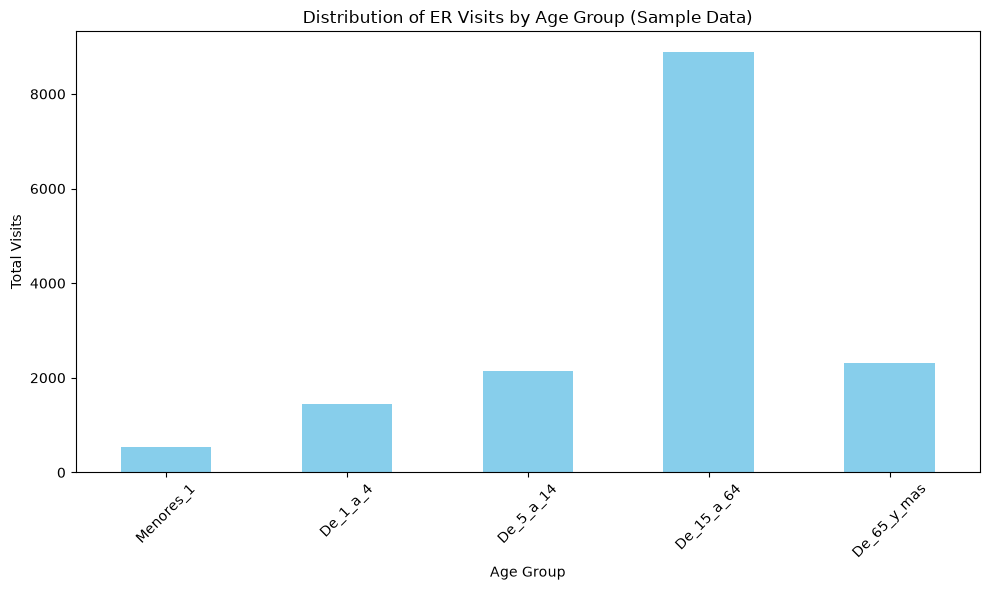


--- Textual Data Output for the Plot ---
Data: Distribution of ER Visits by Age Group
             Total Visits
Menores_1             527
De_1_a_4             1439
De_5_a_14            2134
De_15_a_64           8880
De_65_y_mas          2315
------------------------------------------


In [3]:
# Group by age group to see distribution
# Age columns: 'Menores_1', 'De_1_a_4', 'De_5_a_14', 'De_15_a_64', 'De_65_y_mas'
age_columns = ['Menores_1', 'De_1_a_4', 'De_5_a_14', 'De_15_a_64', 'De_65_y_mas']

# Sum the columns for our sample
age_distribution = df_er[age_columns].sum()

# Plotting the data
plt.figure(figsize=(10, 6))
age_distribution.plot(kind='bar', color='skyblue')
plt.title('Distribution of ER Visits by Age Group (Sample Data)')
plt.xlabel('Age Group')
plt.ylabel('Total Visits')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# REQUIRED TEXT OUTPUT (Project Rule 3)
print("\n--- Textual Data Output for the Plot ---")
print("Data: Distribution of ER Visits by Age Group")
print(age_distribution.to_frame(name='Total Visits').to_string())
print("------------------------------------------")